In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

In [19]:
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
print("Shape:", df.shape)

Shape: (150, 5)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [23]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [24]:
df["species"].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


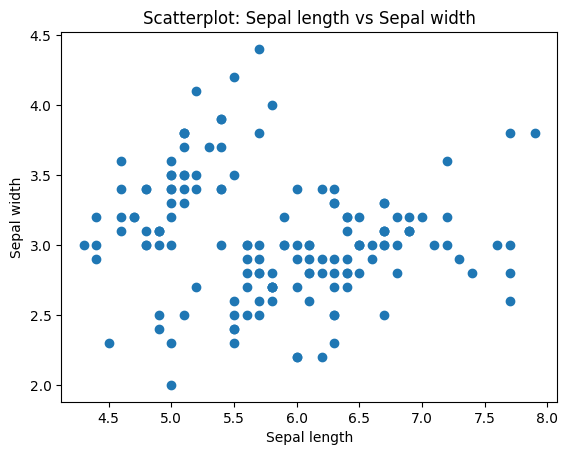

In [25]:
plt.figure()
plt.scatter(df['sepal_length'],df['sepal_width'])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Scatterplot: Sepal length vs Sepal width')
plt.show()

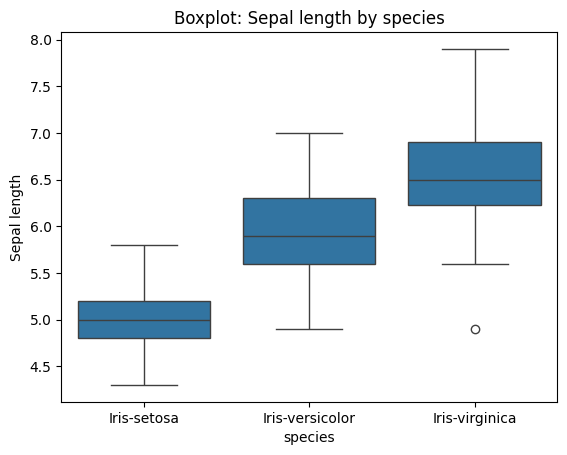

In [26]:
plt.figure()
sn.boxplot(x='species',y='sepal_length',data=df)
plt.xlabel('species')
plt.ylabel('Sepal length')
plt.title('Boxplot: Sepal length by species')
plt.show()

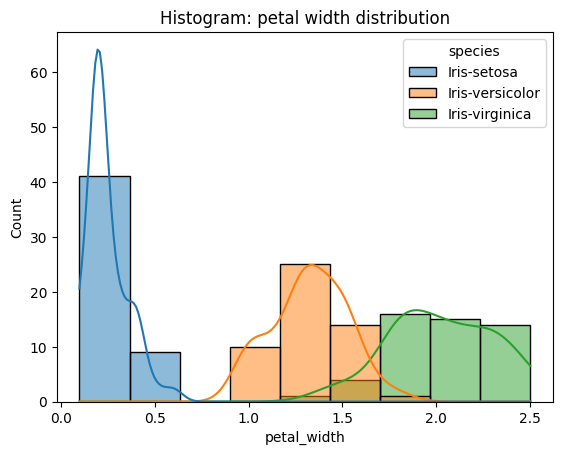

In [27]:
plt.figure()
sn.histplot(x='petal_width',hue='species',data=df,kde=True)
plt.title('Histogram: petal width distribution')
plt.show()

<Figure size 640x480 with 0 Axes>

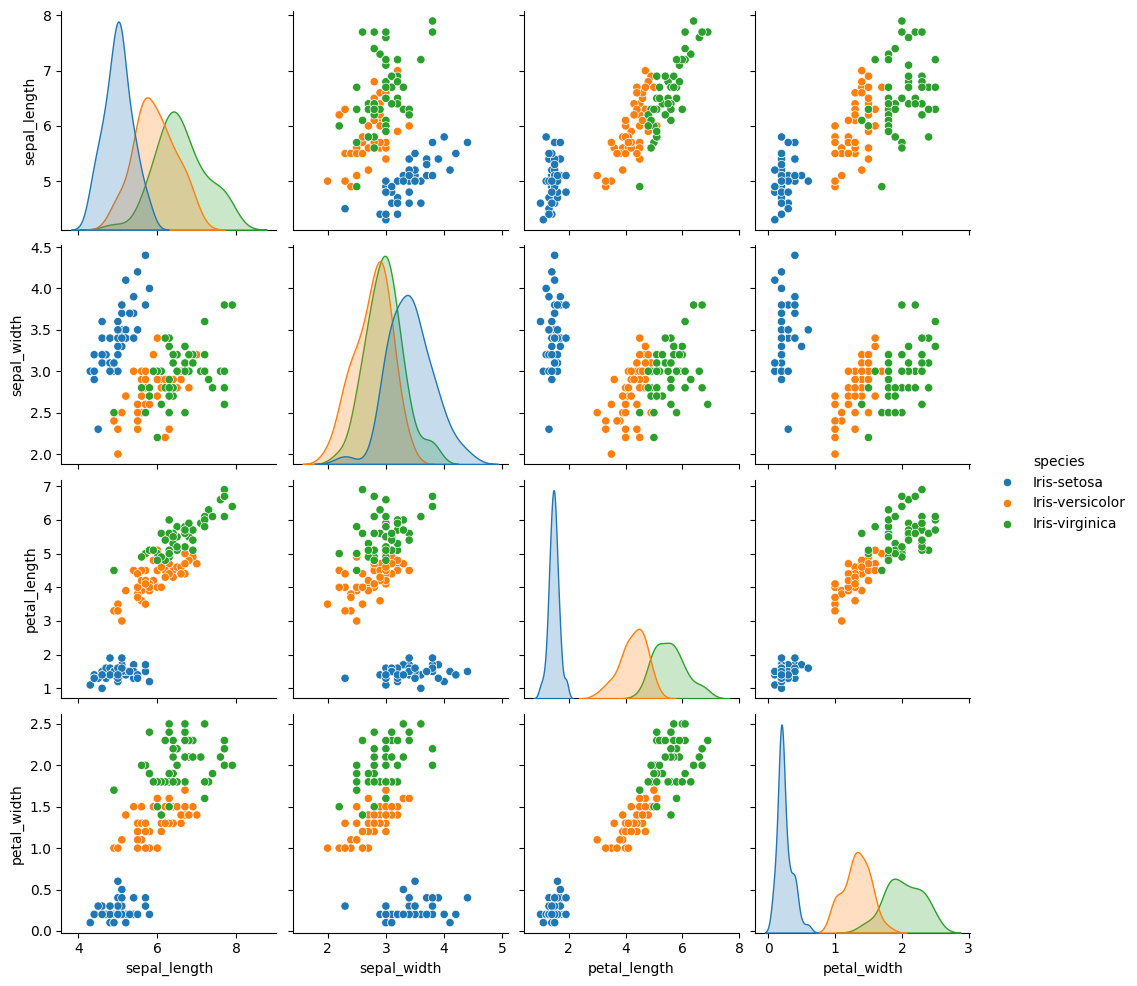

In [28]:
plt.figure()
sn.pairplot(df,hue='species')
plt.show()

In [29]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
x = df.drop('species',axis=1)
y = df['species']

In [33]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
    )

In [35]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
knn_pred = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test,knn_pred)
print("Accuracy:",knn_accuracy)

Accuracy: 0.9333333333333333


In [42]:
lr_model = LogisticRegression(max_iter = 200)
lr_model.fit(x_train,y_train)
lr_pred = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test,lr_pred)
print("Accuracy:",lr_accuracy)

Accuracy: 0.9333333333333333


In [43]:
dtr_model = DecisionTreeClassifier(random_state = 42)
dtr_model.fit(x_train,y_train)
dtr_pred = dtr_model.predict(x_test)
dtr_accuracy = accuracy_score(y_test,dtr_pred)
print("Accuracy:",dtr_accuracy)

Accuracy: 0.9


In [45]:
result = pd.DataFrame({ "Model":['knn_model','lr_model','dtr_model'],
                        "Accuracy":[knn_accuracy,lr_accuracy,dtr_accuracy]
                        })
result = result.sort_values(by='Accuracy',ascending=False)
result

,Model,Accuracy
0,knn_model,0.933333
1,lr_model,0.933333
2,dtr_model,0.900000


In [46]:
best_model_name = result.loc[
    result["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: knn_model


In [47]:
best_model = knn_model
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [50]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n",conf_matrix)

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [52]:
species_names = encoder.classes_
print(classification_report
 (
    y_test,
    y_pred,
    target_names=species_names
  )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [53]:
joblib.dump(
    best_model,
    "iris_model.pkl"
)
print('Model saved!')

Model saved!


In [54]:
joblib.dump(
    scaler,
    "scaler.pkl"
)
print('scaler saved!')

scaler saved!


In [59]:
# This is an example inference code....

model = joblib.load('iris_model.pkl')
scaler = joblib.load('scaler.pkl')

sample = [[6.0,2.9,4.5,1.5]]
sample = scaler.transform(sample)
prediction = model.predict(sample)
print('Prediction Species: ', encoder.inverse_transform(prediction)[0])

Prediction Species:  Iris-versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
